# Trajectory path-error metrics: SINGLE (Comment 26)

Fig. 6 currently reports only qualitative circle plots and a single mean +/-
std angular value; the reviewer asks for a quantitative path-error metric
(RMS radial / height deviation from the reference circle). Computed here
directly from the logged `Polygon*.npz` trajectories -- the circle
center/radius are re-fit from each file's own commanded vertices (Kasa
least-squares circle fit), so this doesn't depend on assumptions about the
generation code's exact conventions. See `path_error_metrics.py`.

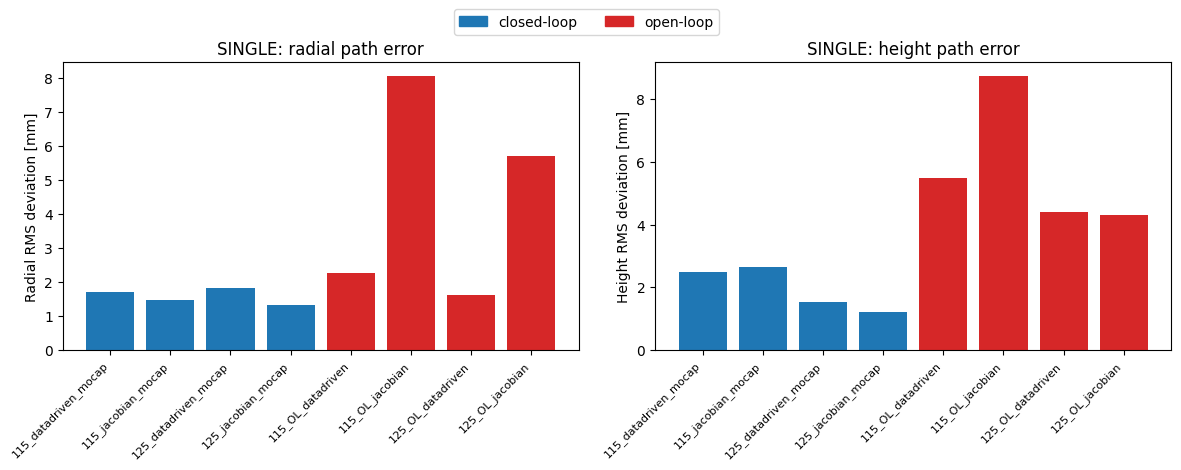

In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt

with open("results/PathErrorMetrics_closed.json") as f:
    single_cl = json.load(f)
with open("results/PathErrorMetrics_open.json") as f:
    single_ol = json.load(f)

def short_name(k):
    return k.split("/")[-1].replace("PolygonWS_30_", "").replace(".npz", "")

labels = [short_name(k) for k in single_cl] + [short_name(k) for k in single_ol]
radial = [v["radial_rms"] for v in single_cl.values()] + [v["radial_rms"] for v in single_ol.values()]
height = [v["height_rms"] for v in single_cl.values()] + [v["height_rms"] for v in single_ol.values()]
colors = ["#1f77b4"]*len(single_cl) + ["#d62728"]*len(single_ol)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(labels))
axes[0].bar(x, radial, color=colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Radial RMS deviation [mm]"); axes[0].set_title("SINGLE: radial path error")

axes[1].bar(x, height, color=colors)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Height RMS deviation [mm]"); axes[1].set_title("SINGLE: height path error")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="#1f77b4", label="closed-loop"), Patch(color="#d62728", label="open-loop")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.savefig("results/single_path_error.pdf", bbox_inches="tight")
plt.show()
